In [669]:
import pandas as pd
import numpy as np
import json

In [670]:
with open('churn_nordeste_raw.json', 'r') as f:
    json_bruto = json.load(f)

In [671]:
json_bruto

{'regional': 'Nordeste',
 'data_extracao': '2026-02-13',
 'clientes': [{'id_cliente': 'NE-10201',
   'info_pessoal': {'genero': 'Masculino',
    'idoso': 0,
    'parceiro': 'Sim',
    'dependentes': 'Nao'},
   'conta': {'meses_contrato': 12,
    'tipo_contrato': 'Mensal',
    'pagamento': 'Boleto bancÃ¡rio',
    'cobranca_mensal': '89,90',
    'cobranca_total': '1078,80'},
   'servicos': {'telefone': 'Sim',
    'internet': 'Fibra Ã³tica',
    'seguranca_online': 'Nao',
    'backup_online': 'Nao'},
   'churn': 'Sim'},
  {'id_cliente': 'NE-10202',
   'info_pessoal': {'genero': 'Feminino',
    'idoso': 1,
    'parceiro': 'Nao',
    'dependentes': 'Nao'},
   'conta': {'meses_contrato': 48,
    'tipo_contrato': 'Dois anos',
    'pagamento': 'CartÃ£o de crÃ©dito',
    'cobranca_mensal': '45,50',
    'cobranca_total': '2184,00'},
   'servicos': {'telefone': 'Sim',
    'internet': 'DSL',
    'seguranca_online': 'Sim',
    'backup_online': 'Sim'},
   'churn': 'Nao'},
  {'id_cliente': 'NE-10203'

In [672]:
dados_normalizados = pd.json_normalize(data=json_bruto, record_path='clientes', meta=['regional', 'data_extracao'], sep='_')

In [673]:
dados_normalizados

,id_cliente,churn,info_pessoal_genero,info_pessoal_idoso,info_pessoal_parceiro,info_pessoal_dependentes,conta_meses_contrato,conta_tipo_contrato,conta_pagamento,conta_cobranca_mensal,conta_cobranca_total,servicos_telefone,servicos_internet,servicos_seguranca_online,servicos_backup_online,regional,data_extracao
0,NE-10201,Sim,Masculino,0,Sim,Nao,12,Mensal,Boleto bancÃ¡rio,"89,90","1078,80",Sim,Fibra Ã³tica,Nao,Nao,Nordeste,2026-02-13
1,NE-10202,Nao,Feminino,1,Nao,Nao,48,Dois anos,CartÃ£o de crÃ©dito,"45,50","2184,00",Sim,DSL,Sim,Sim,Nordeste,2026-02-13
2,NE-10203,Sim,Masculino,0,Sim,Sim,2,Mensal,DÃ©bito automÃ¡tico,"120,00","240,00",Nao,Fibra Ã³tica,Sim,Nao,Nordeste,2026-02-13
3,NE-10204,Nao,Feminino,0,Sim,Nao,24,Um ano,Boleto bancÃ¡rio,"75,30","1807,20",Sim,Fibra Ã³tica,Nao,Sim,Nordeste,2026-02-13
4,NE-10205,Sim,Feminino,1,Nao,Nao,1,Mensal,Boleto bancÃ¡rio,"99,99","99,99",Sim,Fibra Ã³tica,Nao,Nao,Nordeste,2026-02-13
5,NE-10206,Nao,Masculino,0,Nao,Nao,36,Dois anos,CartÃ£o de crÃ©dito,"55,00","1980,00",Sim,DSL,Sim,Sim,Nordeste,2026-02-13
6,NE-10207,Nao,Masculino,0,Sim,Sim,8,Mensal,Boleto bancÃ¡rio,"110,50","884,00",Sim,Fibra Ã³tica,Nao,Nao,Nordeste,2026-02-13
7,NE-10208,Nao,Feminino,1,Nao,Nao,15,Um ano,DÃ©bito automÃ¡tico,"65,00","975,00",Nao,DSL,Sim,Sim,Nordeste,2026-02-13
8,NE-10209,Nao,Masculino,0,Nao,Nao,450,Mensal,Boleto bancÃ¡rio,"70,00","31500,00",Sim,Fibra Ã³tica,Nao,Nao,Nordeste,2026-02-13
9,NE-10210,Sim,Feminino,0,Sim,Sim,18,Um ano,CartÃ£o de crÃ©dito,"0,01","0,18",Nao,DSL,Nao,Nao,Nordeste,2026-02-13


In [674]:
dados_normalizados.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   id_cliente                 15 non-null     str  
 1   churn                      15 non-null     str  
 2   info_pessoal_genero        15 non-null     str  
 3   info_pessoal_idoso         15 non-null     int64
 4   info_pessoal_parceiro      15 non-null     str  
 5   info_pessoal_dependentes   15 non-null     str  
 6   conta_meses_contrato       15 non-null     int64
 7   conta_tipo_contrato        15 non-null     str  
 8   conta_pagamento            15 non-null     str  
 9   conta_cobranca_mensal      15 non-null     str  
 10  conta_cobranca_total       15 non-null     str  
 11  servicos_telefone          15 non-null     str  
 12  servicos_internet          15 non-null     str  
 13  servicos_seguranca_online  15 non-null     str  
 14  servicos_backup_online     15 non-null 

In [675]:
dados_normalizados[['conta_cobranca_mensal', 'conta_cobranca_total']] = dados_normalizados[['conta_cobranca_mensal', 'conta_cobranca_total']].replace(',', '.', regex=True)

In [676]:
dados_normalizados['conta_cobranca_mensal'] = pd.to_numeric(dados_normalizados['conta_cobranca_mensal'], errors='coerce')
dados_normalizados['conta_cobranca_total'] = pd.to_numeric(dados_normalizados['conta_cobranca_total'], errors='coerce')

In [677]:
dados_normalizados.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15 non-null     str    
 1   churn                      15 non-null     str    
 2   info_pessoal_genero        15 non-null     str    
 3   info_pessoal_idoso         15 non-null     int64  
 4   info_pessoal_parceiro      15 non-null     str    
 5   info_pessoal_dependentes   15 non-null     str    
 6   conta_meses_contrato       15 non-null     int64  
 7   conta_tipo_contrato        15 non-null     str    
 8   conta_pagamento            15 non-null     str    
 9   conta_cobranca_mensal      15 non-null     float64
 10  conta_cobranca_total       15 non-null     float64
 11  servicos_telefone          15 non-null     str    
 12  servicos_internet          15 non-null     str    
 13  servicos_seguranca_online  15 non-null     str    
 14  servico

In [678]:
dados_normalizados

,id_cliente,churn,info_pessoal_genero,info_pessoal_idoso,info_pessoal_parceiro,info_pessoal_dependentes,conta_meses_contrato,conta_tipo_contrato,conta_pagamento,conta_cobranca_mensal,conta_cobranca_total,servicos_telefone,servicos_internet,servicos_seguranca_online,servicos_backup_online,regional,data_extracao
0,NE-10201,Sim,Masculino,0,Sim,Nao,12,Mensal,Boleto bancÃ¡rio,89.90,1078.80,Sim,Fibra Ã³tica,Nao,Nao,Nordeste,2026-02-13
1,NE-10202,Nao,Feminino,1,Nao,Nao,48,Dois anos,CartÃ£o de crÃ©dito,45.50,2184.00,Sim,DSL,Sim,Sim,Nordeste,2026-02-13
2,NE-10203,Sim,Masculino,0,Sim,Sim,2,Mensal,DÃ©bito automÃ¡tico,120.00,240.00,Nao,Fibra Ã³tica,Sim,Nao,Nordeste,2026-02-13
3,NE-10204,Nao,Feminino,0,Sim,Nao,24,Um ano,Boleto bancÃ¡rio,75.30,1807.20,Sim,Fibra Ã³tica,Nao,Sim,Nordeste,2026-02-13
4,NE-10205,Sim,Feminino,1,Nao,Nao,1,Mensal,Boleto bancÃ¡rio,99.99,99.99,Sim,Fibra Ã³tica,Nao,Nao,Nordeste,2026-02-13
5,NE-10206,Nao,Masculino,0,Nao,Nao,36,Dois anos,CartÃ£o de crÃ©dito,55.00,1980.00,Sim,DSL,Sim,Sim,Nordeste,2026-02-13
6,NE-10207,Nao,Masculino,0,Sim,Sim,8,Mensal,Boleto bancÃ¡rio,110.50,884.00,Sim,Fibra Ã³tica,Nao,Nao,Nordeste,2026-02-13
7,NE-10208,Nao,Feminino,1,Nao,Nao,15,Um ano,DÃ©bito automÃ¡tico,65.00,975.00,Nao,DSL,Sim,Sim,Nordeste,2026-02-13
8,NE-10209,Nao,Masculino,0,Nao,Nao,450,Mensal,Boleto bancÃ¡rio,70.00,31500.00,Sim,Fibra Ã³tica,Nao,Nao,Nordeste,2026-02-13
9,NE-10210,Sim,Feminino,0,Sim,Sim,18,Um ano,CartÃ£o de crÃ©dito,0.01,0.18,Nao,DSL,Nao,Nao,Nordeste,2026-02-13


In [679]:
colunas = dados_normalizados.select_dtypes('str').columns

In [680]:
colunas

Index(['id_cliente', 'churn', 'info_pessoal_genero', 'info_pessoal_parceiro',
       'info_pessoal_dependentes', 'conta_tipo_contrato', 'conta_pagamento',
       'servicos_telefone', 'servicos_internet', 'servicos_seguranca_online',
       'servicos_backup_online', 'regional', 'data_extracao'],
      dtype='str')

In [681]:
dados_normalizados[colunas] = dados_normalizados[colunas].apply(lambda x: x.str.strip()).replace('', np.nan)

In [682]:
dados_normalizados

,id_cliente,churn,info_pessoal_genero,info_pessoal_idoso,info_pessoal_parceiro,info_pessoal_dependentes,conta_meses_contrato,conta_tipo_contrato,conta_pagamento,conta_cobranca_mensal,conta_cobranca_total,servicos_telefone,servicos_internet,servicos_seguranca_online,servicos_backup_online,regional,data_extracao
0,NE-10201,Sim,Masculino,0,Sim,Nao,12,Mensal,Boleto bancÃ¡rio,89.90,1078.80,Sim,Fibra Ã³tica,Nao,Nao,Nordeste,2026-02-13
1,NE-10202,Nao,Feminino,1,Nao,Nao,48,Dois anos,CartÃ£o de crÃ©dito,45.50,2184.00,Sim,DSL,Sim,Sim,Nordeste,2026-02-13
2,NE-10203,Sim,Masculino,0,Sim,Sim,2,Mensal,DÃ©bito automÃ¡tico,120.00,240.00,Nao,Fibra Ã³tica,Sim,Nao,Nordeste,2026-02-13
3,NE-10204,Nao,Feminino,0,Sim,Nao,24,Um ano,Boleto bancÃ¡rio,75.30,1807.20,Sim,Fibra Ã³tica,Nao,Sim,Nordeste,2026-02-13
4,NE-10205,Sim,Feminino,1,Nao,Nao,1,Mensal,Boleto bancÃ¡rio,99.99,99.99,Sim,Fibra Ã³tica,Nao,Nao,Nordeste,2026-02-13
5,NE-10206,Nao,Masculino,0,Nao,Nao,36,Dois anos,CartÃ£o de crÃ©dito,55.00,1980.00,Sim,DSL,Sim,Sim,Nordeste,2026-02-13
6,NE-10207,Nao,Masculino,0,Sim,Sim,8,Mensal,Boleto bancÃ¡rio,110.50,884.00,Sim,Fibra Ã³tica,Nao,Nao,Nordeste,2026-02-13
7,NE-10208,Nao,Feminino,1,Nao,Nao,15,Um ano,DÃ©bito automÃ¡tico,65.00,975.00,Nao,DSL,Sim,Sim,Nordeste,2026-02-13
8,NE-10209,Nao,Masculino,0,Nao,Nao,450,Mensal,Boleto bancÃ¡rio,70.00,31500.00,Sim,Fibra Ã³tica,Nao,Nao,Nordeste,2026-02-13
9,NE-10210,Sim,Feminino,0,Sim,Sim,18,Um ano,CartÃ£o de crÃ©dito,0.01,0.18,Nao,DSL,Nao,Nao,Nordeste,2026-02-13


In [683]:
quantidade_nulos = dados_normalizados.isna().sum().sum()

In [684]:
print(f'Não há necessidade de tratar nulos, pois eles não existem após as conversões de tipos e tratamento de strings vazias. Conforme variável "quantidade_nulos" o número é: {quantidade_nulos}')

Não há necessidade de tratar nulos, pois eles não existem após as conversões de tipos e tratamento de strings vazias. Conforme variável "quantidade_nulos" o número é: 0


In [685]:
quantidade_duplicatas = dados_normalizados.duplicated().sum()

In [686]:
print(f'Não há necessidade de tratar duplicatas, pois elas não existem, conforme valor indicado na variável "quantidade_duplicatas": {quantidade_duplicatas}')

Não há necessidade de tratar duplicatas, pois elas não existem, conforme valor indicado na variável "quantidade_duplicatas": 0


In [687]:
dados_normalizados.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15 non-null     str    
 1   churn                      15 non-null     str    
 2   info_pessoal_genero        15 non-null     str    
 3   info_pessoal_idoso         15 non-null     int64  
 4   info_pessoal_parceiro      15 non-null     str    
 5   info_pessoal_dependentes   15 non-null     str    
 6   conta_meses_contrato       15 non-null     int64  
 7   conta_tipo_contrato        15 non-null     str    
 8   conta_pagamento            15 non-null     str    
 9   conta_cobranca_mensal      15 non-null     float64
 10  conta_cobranca_total       15 non-null     float64
 11  servicos_telefone          15 non-null     str    
 12  servicos_internet          15 non-null     str    
 13  servicos_seguranca_online  15 non-null     str    
 14  servico

In [688]:
dados_normalizados.select_dtypes(exclude='str')

,info_pessoal_idoso,conta_meses_contrato,conta_cobranca_mensal,conta_cobranca_total
0,0,12,89.90,1078.80
1,1,48,45.50,2184.00
2,0,2,120.00,240.00
3,0,24,75.30,1807.20
4,1,1,99.99,99.99
5,0,36,55.00,1980.00
6,0,8,110.50,884.00
7,1,15,65.00,975.00
8,0,450,70.00,31500.00
9,0,18,0.01,0.18


<Axes: xlabel='conta_meses_contrato'>

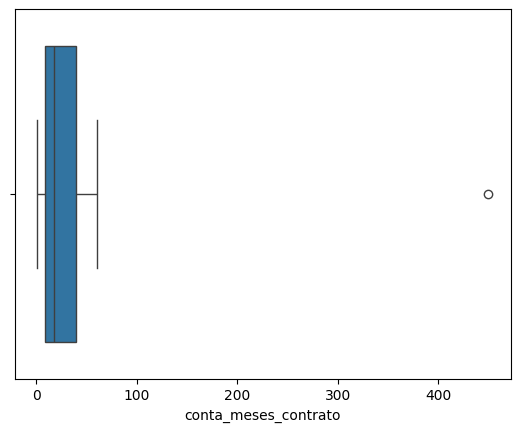

In [689]:
sns.boxplot(x=dados_normalizados['conta_meses_contrato'])

In [690]:
def calc_outliers(column, dataframe):
    Q1 = dataframe[column].quantile(.25)
    Q3 = dataframe[column].quantile(.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - (1.5 * IQR)
    limite_superior = Q3 + (1.5 * IQR)

    outliers_index = (dataframe[column] < limite_inferior) | (dataframe[column] > limite_superior)

    if((dataframe[column] < limite_inferior).any()):
        dataframe.loc[dataframe[column] < limite_inferior, column] = limite_inferior

    if((dataframe[column] > limite_superior).any()):
        dataframe.loc[dataframe[column] > limite_superior, column] = limite_superior
    
    return dataframe

In [691]:
dados_normalizados = calc_outliers('conta_meses_contrato', dados_normalizados)

In [692]:
dados_normalizados = calc_outliers('conta_cobranca_mensal', dados_normalizados)

In [693]:
dados_normalizados = calc_outliers('conta_cobranca_total', dados_normalizados)

In [694]:
dados_normalizados[['conta_meses_contrato', 'conta_cobranca_mensal', 'conta_cobranca_total']]

,conta_meses_contrato,conta_cobranca_mensal,conta_cobranca_total
0,12,89.9000,1078.80
1,48,45.5000,2184.00
2,2,120.0000,240.00
3,24,75.3000,1807.20
4,1,99.9900,99.99
5,36,55.0000,1980.00
6,8,110.5000,884.00
7,15,65.0000,975.00
8,84,70.0000,4857.00
9,18,0.0100,0.18


<Axes: xlabel='conta_meses_contrato'>

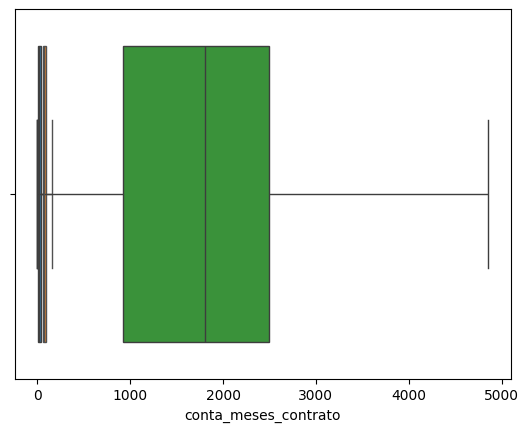

In [695]:
sns.boxplot(x=dados_normalizados['conta_meses_contrato'])
sns.boxplot(x=dados_normalizados['conta_cobranca_mensal'])
sns.boxplot(x=dados_normalizados['conta_cobranca_total'])

In [696]:
dados_normalizados = dados_normalizados.drop(columns=['regional', 'data_extracao'])

In [697]:
dados_normalizados.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15 non-null     str    
 1   churn                      15 non-null     str    
 2   info_pessoal_genero        15 non-null     str    
 3   info_pessoal_idoso         15 non-null     int64  
 4   info_pessoal_parceiro      15 non-null     str    
 5   info_pessoal_dependentes   15 non-null     str    
 6   conta_meses_contrato       15 non-null     int64  
 7   conta_tipo_contrato        15 non-null     str    
 8   conta_pagamento            15 non-null     str    
 9   conta_cobranca_mensal      15 non-null     float64
 10  conta_cobranca_total       15 non-null     float64
 11  servicos_telefone          15 non-null     str    
 12  servicos_internet          15 non-null     str    
 13  servicos_seguranca_online  15 non-null     str    
 14  servico

In [698]:
colunas_categoricas_binarias = []
colunas_categoricas_multicategoria = []

for col in dados_normalizados.select_dtypes(include='str'):
    if(len(dados_normalizados[col].unique()) == 2 and dados_normalizados[col].name != 'servicos_internet' and dados_normalizados[col].name != 'id_cliente'):
        colunas_categoricas_binarias.append(dados_normalizados[col].name)
    elif((len(dados_normalizados[col].unique()) > 2 or dados_normalizados[col].name == 'servicos_internet') and dados_normalizados[col].name != 'id_cliente'):
        colunas_categoricas_multicategoria.append(dados_normalizados[col].name)

In [699]:
colunas_categoricas_binarias

['churn',
 'info_pessoal_genero',
 'info_pessoal_parceiro',
 'info_pessoal_dependentes',
 'servicos_telefone',
 'servicos_seguranca_online',
 'servicos_backup_online']

In [700]:
colunas_categoricas_multicategoria

['conta_tipo_contrato', 'conta_pagamento', 'servicos_internet']

In [701]:
mapeamento_binarias = {
    'Sim': 1,
    'Nao': 0,
}

In [702]:
dados_normalizados = dados_normalizados.replace(mapeamento_binarias)
dados_normalizados

,id_cliente,churn,info_pessoal_genero,info_pessoal_idoso,info_pessoal_parceiro,info_pessoal_dependentes,conta_meses_contrato,conta_tipo_contrato,conta_pagamento,conta_cobranca_mensal,conta_cobranca_total,servicos_telefone,servicos_internet,servicos_seguranca_online,servicos_backup_online
0,NE-10201,1,Masculino,0,1,0,12,Mensal,Boleto bancÃ¡rio,89.9000,1078.80,1,Fibra Ã³tica,0,0
1,NE-10202,0,Feminino,1,0,0,48,Dois anos,CartÃ£o de crÃ©dito,45.5000,2184.00,1,DSL,1,1
2,NE-10203,1,Masculino,0,1,1,2,Mensal,DÃ©bito automÃ¡tico,120.0000,240.00,0,Fibra Ã³tica,1,0
3,NE-10204,0,Feminino,0,1,0,24,Um ano,Boleto bancÃ¡rio,75.3000,1807.20,1,Fibra Ã³tica,0,1
4,NE-10205,1,Feminino,1,0,0,1,Mensal,Boleto bancÃ¡rio,99.9900,99.99,1,Fibra Ã³tica,0,0
5,NE-10206,0,Masculino,0,0,0,36,Dois anos,CartÃ£o de crÃ©dito,55.0000,1980.00,1,DSL,1,1
6,NE-10207,0,Masculino,0,1,1,8,Mensal,Boleto bancÃ¡rio,110.5000,884.00,1,Fibra Ã³tica,0,0
7,NE-10208,0,Feminino,1,0,0,15,Um ano,DÃ©bito automÃ¡tico,65.0000,975.00,0,DSL,1,1
8,NE-10209,0,Masculino,0,0,0,84,Mensal,Boleto bancÃ¡rio,70.0000,4857.00,1,Fibra Ã³tica,0,0
9,NE-10210,1,Feminino,0,1,1,18,Um ano,CartÃ£o de crÃ©dito,0.0100,0.18,0,DSL,0,0


In [703]:
mapeamento_generos = {
    'Masculino': 1,
    'Feminino': 0
}

In [704]:
dados_normalizados = dados_normalizados.replace(mapeamento_generos)
dados_normalizados

# Destaca-se que a atribuição de 'Masculino' para 1 e 'Feminino' para 0 é arbitrária.

,id_cliente,churn,info_pessoal_genero,info_pessoal_idoso,info_pessoal_parceiro,info_pessoal_dependentes,conta_meses_contrato,conta_tipo_contrato,conta_pagamento,conta_cobranca_mensal,conta_cobranca_total,servicos_telefone,servicos_internet,servicos_seguranca_online,servicos_backup_online
0,NE-10201,1,1,0,1,0,12,Mensal,Boleto bancÃ¡rio,89.9000,1078.80,1,Fibra Ã³tica,0,0
1,NE-10202,0,0,1,0,0,48,Dois anos,CartÃ£o de crÃ©dito,45.5000,2184.00,1,DSL,1,1
2,NE-10203,1,1,0,1,1,2,Mensal,DÃ©bito automÃ¡tico,120.0000,240.00,0,Fibra Ã³tica,1,0
3,NE-10204,0,0,0,1,0,24,Um ano,Boleto bancÃ¡rio,75.3000,1807.20,1,Fibra Ã³tica,0,1
4,NE-10205,1,0,1,0,0,1,Mensal,Boleto bancÃ¡rio,99.9900,99.99,1,Fibra Ã³tica,0,0
5,NE-10206,0,1,0,0,0,36,Dois anos,CartÃ£o de crÃ©dito,55.0000,1980.00,1,DSL,1,1
6,NE-10207,0,1,0,1,1,8,Mensal,Boleto bancÃ¡rio,110.5000,884.00,1,Fibra Ã³tica,0,0
7,NE-10208,0,0,1,0,0,15,Um ano,DÃ©bito automÃ¡tico,65.0000,975.00,0,DSL,1,1
8,NE-10209,0,1,0,0,0,84,Mensal,Boleto bancÃ¡rio,70.0000,4857.00,1,Fibra Ã³tica,0,0
9,NE-10210,1,0,0,1,1,18,Um ano,CartÃ£o de crÃ©dito,0.0100,0.18,0,DSL,0,0


In [705]:
dados_normalizados.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15 non-null     str    
 1   churn                      15 non-null     object 
 2   info_pessoal_genero        15 non-null     object 
 3   info_pessoal_idoso         15 non-null     int64  
 4   info_pessoal_parceiro      15 non-null     object 
 5   info_pessoal_dependentes   15 non-null     object 
 6   conta_meses_contrato       15 non-null     int64  
 7   conta_tipo_contrato        15 non-null     str    
 8   conta_pagamento            15 non-null     str    
 9   conta_cobranca_mensal      15 non-null     float64
 10  conta_cobranca_total       15 non-null     float64
 11  servicos_telefone          15 non-null     object 
 12  servicos_internet          15 non-null     str    
 13  servicos_seguranca_online  15 non-null     object 
 14  servico

In [706]:
dados_normalizados = pd.get_dummies(dados_normalizados, columns=colunas_categoricas_multicategoria, dtype='int', drop_first=True)

# Como só existem 3 tipos de dados tanto para a coluna 'conta_tipo_contrato' quanto 'conta_pagamento',
# faz sentido utilizar o parâmetro 'drop_first', pois sempre que duas colunas do mesmo tipo tiver valores 0,
# isso significará que o valor é de um terceiro tipo.
# Por exemplo, se 'conta_tipo_contrato_Mensal' e 'conta_tipo_contrato_Um ano' tiverem valor 0, então 'conta_tipo_contrato_Dois anos' existe, ou seja, terá valor 1.

In [707]:
dados_normalizados

,id_cliente,churn,info_pessoal_genero,info_pessoal_idoso,info_pessoal_parceiro,info_pessoal_dependentes,conta_meses_contrato,conta_cobranca_mensal,conta_cobranca_total,servicos_telefone,servicos_seguranca_online,servicos_backup_online,conta_tipo_contrato_Mensal,conta_tipo_contrato_Um ano,conta_pagamento_CartÃ£o de crÃ©dito,conta_pagamento_DÃ©bito automÃ¡tico,servicos_internet_Fibra Ã³tica
0,NE-10201,1,1,0,1,0,12,89.9000,1078.80,1,0,0,1,0,0,0,1
1,NE-10202,0,0,1,0,0,48,45.5000,2184.00,1,1,1,0,0,1,0,0
2,NE-10203,1,1,0,1,1,2,120.0000,240.00,0,1,0,1,0,0,1,1
3,NE-10204,0,0,0,1,0,24,75.3000,1807.20,1,0,1,0,1,0,0,1
4,NE-10205,1,0,1,0,0,1,99.9900,99.99,1,0,0,1,0,0,0,1
5,NE-10206,0,1,0,0,0,36,55.0000,1980.00,1,1,1,0,0,1,0,0
6,NE-10207,0,1,0,1,1,8,110.5000,884.00,1,0,0,1,0,0,0,1
7,NE-10208,0,0,1,0,0,15,65.0000,975.00,0,1,1,0,1,0,1,0
8,NE-10209,0,1,0,0,0,84,70.0000,4857.00,1,0,0,1,0,0,0,1
9,NE-10210,1,0,0,1,1,18,0.0100,0.18,0,0,0,0,1,1,0,0


In [708]:
for col in dados_normalizados[colunas_categoricas_binarias]:
    dados_normalizados[col] = pd.to_numeric(dados_normalizados[col])

In [709]:
dados_normalizados.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id_cliente                           15 non-null     str    
 1   churn                                15 non-null     int64  
 2   info_pessoal_genero                  15 non-null     int64  
 3   info_pessoal_idoso                   15 non-null     int64  
 4   info_pessoal_parceiro                15 non-null     int64  
 5   info_pessoal_dependentes             15 non-null     int64  
 6   conta_meses_contrato                 15 non-null     int64  
 7   conta_cobranca_mensal                15 non-null     float64
 8   conta_cobranca_total                 15 non-null     float64
 9   servicos_telefone                    15 non-null     int64  
 10  servicos_seguranca_online            15 non-null     int64  
 11  servicos_backup_online               15 non-n

In [ ]:
dados_normalizados.info()

# Após todas as transformações, o DataFrame final não tem as colunas 'regional' e 'data_extracao',
# pois elas não possuem dados que são relevantes para o Modelo. A coluna 'regional' possui somente o valor 'nordeste'
# e a coluna 'data_extracao' somente o valor '2026-02-13'.
# Ademais, a coluna 'id_cliente' é do tipo 'string' e as demais são 'int64'.


<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   id_cliente                           15 non-null     str  
 1   churn                                15 non-null     int64
 2   info_pessoal_genero                  15 non-null     int64
 3   info_pessoal_parceiro                15 non-null     int64
 4   info_pessoal_dependentes             15 non-null     int64
 5   servicos_telefone                    15 non-null     int64
 6   servicos_internet                    15 non-null     int64
 7   servicos_seguranca_online            15 non-null     int64
 8   servicos_backup_online               15 non-null     int64
 9   conta_tipo_contrato_Mensal           15 non-null     int64
 10  conta_tipo_contrato_Um ano           15 non-null     int64
 11  conta_pagamento_CartÃ£o de crÃ©dito  15 non-null     int64
 12  conta_p

In [711]:
print(dados_normalizados.head().to_string())

  id_cliente  churn  info_pessoal_genero  info_pessoal_idoso  info_pessoal_parceiro  info_pessoal_dependentes  conta_meses_contrato  conta_cobranca_mensal  conta_cobranca_total  servicos_telefone  servicos_seguranca_online  servicos_backup_online  conta_tipo_contrato_Mensal  conta_tipo_contrato_Um ano  conta_pagamento_CartÃ£o de crÃ©dito  conta_pagamento_DÃ©bito automÃ¡tico  servicos_internet_Fibra Ã³tica
0   NE-10201      1                    1                   0                      1                         0                    12                  89.90               1078.80                  1                          0                       0                           1                           0                                    0                                    0                               1
1   NE-10202      0                    0                   1                      0                         0                    48                  45.50               2184.00      

In [712]:
dados_normalizados.to_csv('churn_nordeste_ml_ready.csv', sep=';', encoding='utf-8', index=False)